In [378]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importar los data sets

## Hogares

In [455]:
#Importamos el data set
test_hogares = pd.read_csv("test_hogares.csv")
test_hogares.head()
test_vars_h = test_hogares.columns
test_hogares

,id,Clase,Dominio,P5000,P5010,P5090,P5100,P5130,P5140,Nper,Npersug,Li,Lp,Fex_c,Depto,Fex_dpto
0,2a7ddc2779480d7f19834953,1,SANTA MARTA,4,3,1,NaN,400000.0,NaN,5,5,121449.452925,275594.029448,7.826095,47,7.528079
1,a0c2e751e582fd49d564f308,1,SANTA MARTA,4,3,4,NaN,500000.0,NaN,6,6,121449.452925,275594.029448,15.002708,47,15.327736
2,57273d19e8464a5ff66a582b,2,RURAL,3,1,1,NaN,250000.0,NaN,2,2,100763.337626,170886.447382,45.701877,17,50.394748
3,418d052ff7878940ab938601,1,MEDELLIN,4,3,1,NaN,600000.0,NaN,5,5,122251.781628,294093.665341,70.318877,5,80.725068
4,212a37fc17016a3c78f76852,1,MEDELLIN,5,2,2,1800000.0,2000000.0,NaN,2,2,123664.359813,293293.411227,91.241328,5,95.116936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66163,e7d3c7cc62acd33867b7b7ee,1,BARRANQUILLA,3,2,3,NaN,NaN,450000.0,4,4,127610.370110,292192.080210,48.989768,8,48.415863
66164,710db9f02de9c616f846c72e,1,CARTAGENA,3,2,3,NaN,NaN,100000.0,5,5,122811.614203,288078.106437,39.488634,13,32.499700
66165,5a0d6b6fad06e4736fb6d95f,1,ARMENIA,3,2,3,NaN,NaN,250000.0,6,6,121282.133083,278659.892172,10.332009,63,9.719097
66166,569496964b70185785b57789,1,PEREIRA,2,2,4,NaN,300000.0,NaN,5,5,121522.856805,287292.899913,16.470949,66,14.496007


In [456]:
# Importamos el data set
train_hogares = pd.read_csv("train_hogares.csv")
train_hogares.head()
train_vars_h = train_hogares.columns


In [457]:
train_hogares

,id,Clase,Dominio,P5000,P5010,P5090,P5100,P5130,P5140,Nper,...,Ingpcug,Li,Lp,Pobre,Indigente,Npobres,Nindigentes,Fex_c,Depto,Fex_dpto
0,8d0193e328305a042001a35f,1,MEDELLIN,4,2,1,NaN,400000.0,NaN,5,...,5.816661e+05,122809.534158,289878.247150,0,0,0,0,127.222038,5,146.251790
1,cf7491d7f2cc9c216bd009e7,1,MEDELLIN,5,4,3,NaN,NaN,250000.0,4,...,1.612500e+05,122809.534158,289878.247150,1,0,4,0,115.866093,5,93.080952
2,d90a57f64d2a84dbacbed2a5,1,MEDELLIN,4,2,1,NaN,700000.0,NaN,3,...,2.000000e+06,122809.534158,289878.247150,0,0,0,0,100.123276,5,89.637086
3,db34e387a94a783188ab3a33,1,MEDELLIN,3,1,1,NaN,450000.0,NaN,1,...,2.450000e+06,122809.534158,289878.247150,0,0,0,0,108.829812,5,95.584376
4,97bbef785824746ecab09c6f,1,MEDELLIN,4,3,3,NaN,NaN,500000.0,5,...,2.520000e+05,122809.534158,289878.247150,1,0,5,0,110.412859,5,124.560515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164955,0d168c0d27707687fcbf9b60,1,CALI,3,2,3,NaN,NaN,460000.0,3,...,2.824977e+05,127336.653858,280234.432107,0,0,0,0,73.088259,76,77.806334
164956,757f32d9b76aaa11eb93b4a6,1,BOGOTA,3,3,3,NaN,NaN,650000.0,8,...,3.600000e+05,123416.961118,280522.423188,0,0,0,0,413.891448,11,413.891448
164957,ff4ecf438cf2375b8d511645,1,BOGOTA,5,4,1,NaN,2000000.0,NaN,10,...,6.934544e+05,123416.961118,280522.423188,0,0,0,0,233.379248,11,233.379248
164958,5f037d9ddb23a0223d937b30,1,BOGOTA,2,1,3,NaN,NaN,400000.0,4,...,4.799466e+05,123416.961118,280522.423188,0,0,0,0,386.721150,11,386.721150


In [458]:
#Vemos las intersecciones
y_train = train_hogares['Pobre']
columns_inter = test_vars_h.intersection(train_vars_h)
train_hogares = train_hogares[columns_inter]

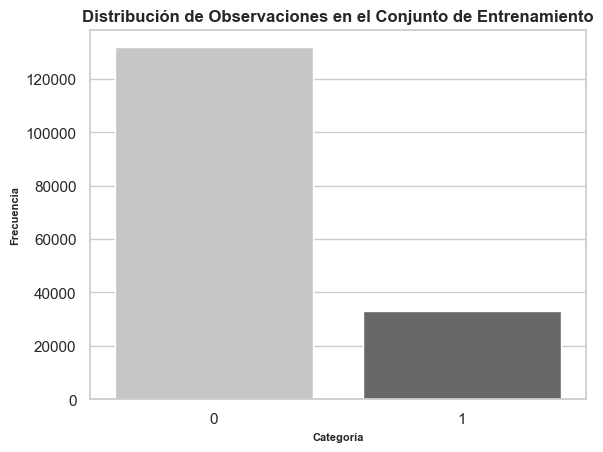

In [459]:
import seaborn as sns
#Gráfico de distribución de Pobreza
count_values = y_train.value_counts().reset_index()
count_values.columns = ['Value', 'Count']

# Crear el gráfico de barras
sns.set_theme(style='whitegrid')
sns.barplot(x='Value', y='Count', data=count_values)

# Añadir etiquetas y título
ax = sns.barplot(x='Value', y='Count', data=count_values, palette='Greys')
ax.set_xlabel('Categoría', fontsize=8, weight='bold')
ax.set_ylabel('Frecuencia', fontsize=8, weight='bold')
ax.set_title('Distribución de Observaciones en el Conjunto de Entrenamiento', fontsize=12, weight='bold')

# Mostrar el gráfico
plt.show()

In [460]:
propor = len(y_train[y_train==0])/len(y_train[y_train==1])
propor

3.99515503875969

## Personas

In [461]:
#Importar el data set
train_personas = pd.read_csv("train_personas.csv")
train_personas.head()
train_vars_p= train_personas.columns
train_personas

,id,Orden,Clase,Dominio,Estrato1,P6020,P6040,P6050,P6090,P6100,...,Iof2es,Iof3hes,Iof3ies,Iof6es,Ingtotob,Ingtotes,Ingtot,Fex_c,Depto,Fex_dpto
0,8d0193e328305a042001a35f,2,1,MEDELLIN,2,2,38,2,1.0,1.0,...,NaN,NaN,NaN,NaN,1.109190e+06,NaN,1.109190e+06,127.222038,5,146.251790
1,8d0193e328305a042001a35f,5,1,MEDELLIN,2,1,3,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
2,8d0193e328305a042001a35f,1,1,MEDELLIN,2,1,41,1,1.0,1.0,...,NaN,NaN,NaN,NaN,1.399140e+06,NaN,1.399140e+06,127.222038,5,146.251790
3,8d0193e328305a042001a35f,4,1,MEDELLIN,2,1,3,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
4,8d0193e328305a042001a35f,3,1,MEDELLIN,2,1,11,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543104,5f037d9ddb23a0223d937b30,2,1,BOGOTA,2,2,24,2,1.0,1.0,...,NaN,NaN,NaN,NaN,1.003667e+06,NaN,1.003667e+06,386.721150,11,386.721150
543105,e575d8c70d587b3be3f45a6f,1,1,BOGOTA,3,2,36,1,1.0,1.0,...,NaN,NaN,NaN,NaN,6.825000e+06,NaN,6.825000e+06,341.056945,11,341.056945
543106,e575d8c70d587b3be3f45a6f,2,1,BOGOTA,3,1,41,2,1.0,1.0,...,NaN,NaN,NaN,NaN,0.000000e+00,NaN,0.000000e+00,341.056945,11,341.056945
543107,e575d8c70d587b3be3f45a6f,3,1,BOGOTA,3,1,8,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,341.056945,11,341.056945


In [462]:
test_personas = pd.read_csv("test_personas.csv")
test_personas

,id,Orden,Clase,Dominio,P6020,P6040,P6050,P6090,P6100,P6210,...,P7510s5,P7510s6,P7510s7,Pet,Oc,Des,Ina,Fex_c,Depto,Fex_dpto
0,3279230a4917cdf883df34cd,1,1,MEDELLIN,1,33,1,1.0,1.0,6.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,125.720226,5,126.041802
1,3279230a4917cdf883df34cd,3,1,MEDELLIN,2,7,3,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.720226,5,126.041802
2,3279230a4917cdf883df34cd,2,1,MEDELLIN,2,37,2,1.0,1.0,6.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,125.720226,5,126.041802
3,3279230a4917cdf883df34cd,4,1,MEDELLIN,1,5,3,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.720226,5,126.041802
4,01bd1f72445acc719d19bd25,1,1,MEDELLIN,1,27,1,1.0,1.0,5.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,73.359246,5,64.143748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219639,95aca5f4d202450cdfc16c37,1,1,RIOHACHA,1,74,1,1.0,2.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219640,95aca5f4d202450cdfc16c37,2,1,RIOHACHA,2,74,2,1.0,2.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219641,95aca5f4d202450cdfc16c37,3,1,RIOHACHA,2,19,4,1.0,1.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219642,95aca5f4d202450cdfc16c37,4,1,RIOHACHA,2,18,4,1.0,1.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896


In [463]:
test_personas.columns

Index(['id', 'Orden', 'Clase', 'Dominio', 'P6020', 'P6040', 'P6050', 'P6090',
       'P6100', 'P6210', 'P6210s1', 'P6240', 'Oficio', 'P6426', 'P6430',
       'P6510', 'P6545', 'P6580', 'P6585s1', 'P6585s2', 'P6585s3', 'P6585s4',
       'P6590', 'P6600', 'P6610', 'P6620', 'P6630s1', 'P6630s2', 'P6630s3',
       'P6630s4', 'P6630s6', 'P6800', 'P6870', 'P6920', 'P7040', 'P7045',
       'P7050', 'P7090', 'P7110', 'P7120', 'P7150', 'P7160', 'P7310', 'P7350',
       'P7422', 'P7472', 'P7495', 'P7500s2', 'P7500s3', 'P7505', 'P7510s1',
       'P7510s2', 'P7510s3', 'P7510s5', 'P7510s6', 'P7510s7', 'Pet', 'Oc',
       'Des', 'Ina', 'Fex_c', 'Depto', 'Fex_dpto'],
      dtype='object')

In [464]:

# Suponiendo que test_personas es tu DataFrame y tienes las columnas mencionadas
columnas = ["P6210","P6020", "P6040", "P6050", "P6090", "Fex_c","P6210s1"]

# Reemplazar los NaNs en cada columna por la media de esa columna
for col in columnas:
    mean_value_t = train_personas[col].mean()
    mean_value = test_personas[col].mean()  # Calcular la media de la columna, ignorando los NaN
    train_personas[col].fillna(mean_value_t, inplace=True)
    test_personas[col].fillna(mean_value, inplace=True)  # Rellenar los NaN con la media

# Mostrar el DataFrame después de la sustitución
#print(test_personas[columnas])


In [465]:
#Importar el data set
test_vars_p = test_personas.columns

In [466]:
#Vemos las intersecciones
columns_inter = test_vars_p.intersection(train_vars_p)
train_personas = train_personas[columns_inter]

In [467]:
test_personas

,id,Orden,Clase,Dominio,P6020,P6040,P6050,P6090,P6100,P6210,...,P7510s5,P7510s6,P7510s7,Pet,Oc,Des,Ina,Fex_c,Depto,Fex_dpto
0,3279230a4917cdf883df34cd,1,1,MEDELLIN,1,33,1,1.000000,1.0,6.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,125.720226,5,126.041802
1,3279230a4917cdf883df34cd,3,1,MEDELLIN,2,7,3,1.069978,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.720226,5,126.041802
2,3279230a4917cdf883df34cd,2,1,MEDELLIN,2,37,2,1.000000,1.0,6.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,125.720226,5,126.041802
3,3279230a4917cdf883df34cd,4,1,MEDELLIN,1,5,3,1.069978,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.720226,5,126.041802
4,01bd1f72445acc719d19bd25,1,1,MEDELLIN,1,27,1,1.000000,1.0,5.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,73.359246,5,64.143748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219639,95aca5f4d202450cdfc16c37,1,1,RIOHACHA,1,74,1,1.000000,2.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219640,95aca5f4d202450cdfc16c37,2,1,RIOHACHA,2,74,2,1.000000,2.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219641,95aca5f4d202450cdfc16c37,3,1,RIOHACHA,2,19,4,1.000000,1.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219642,95aca5f4d202450cdfc16c37,4,1,RIOHACHA,2,18,4,1.000000,1.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896


In [468]:
train_personas

,id,Orden,Clase,Dominio,P6020,P6040,P6050,P6090,P6100,P6210,...,P7510s5,P7510s6,P7510s7,Pet,Oc,Des,Ina,Fex_c,Depto,Fex_dpto
0,8d0193e328305a042001a35f,2,1,MEDELLIN,2,38,2,1.000000,1.0,3.00000,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,127.222038,5,146.251790
1,8d0193e328305a042001a35f,5,1,MEDELLIN,1,3,3,1.071237,NaN,2.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
2,8d0193e328305a042001a35f,1,1,MEDELLIN,1,41,1,1.000000,1.0,5.00000,...,2.0,1.0,2.0,1.0,1.0,NaN,NaN,127.222038,5,146.251790
3,8d0193e328305a042001a35f,4,1,MEDELLIN,1,3,3,1.071237,NaN,2.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
4,8d0193e328305a042001a35f,3,1,MEDELLIN,1,11,3,1.071237,NaN,4.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543104,5f037d9ddb23a0223d937b30,2,1,BOGOTA,2,24,2,1.000000,1.0,5.00000,...,2.0,1.0,2.0,1.0,1.0,NaN,NaN,386.721150,11,386.721150
543105,e575d8c70d587b3be3f45a6f,1,1,BOGOTA,2,36,1,1.000000,1.0,6.00000,...,2.0,1.0,2.0,1.0,1.0,NaN,NaN,341.056945,11,341.056945
543106,e575d8c70d587b3be3f45a6f,2,1,BOGOTA,1,41,2,1.000000,1.0,6.00000,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,341.056945,11,341.056945
543107,e575d8c70d587b3be3f45a6f,3,1,BOGOTA,1,8,3,1.071237,NaN,3.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,341.056945,11,341.056945


## Adición de variables

## Número de personas

## Hacinación

In [469]:
def hacinacion(cuartos, personas):
    return personas/cuartos

#Hacinación
train_hogares["Hasinación"] = hacinacion(train_hogares["P5010"], train_hogares["Nper"])
test_hogares["Hasinación"] = hacinacion(test_hogares["P5010"], test_hogares["Nper"])

C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\2526045470.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_hogares["Hasinación"] = hacinacion(train_hogares["P5010"], train_hogares["Nper"])


## Escolaridad

# Escolaridad máxima

In [470]:
# Definimos la función para calcular el promedio de escolaridad por id
def mean_esco(df2):
    ingresos_agrupados = df2.groupby('id')['P6210s1'].max().reset_index()
    dict_sol = dict(zip(ingresos_agrupados['id'], ingresos_agrupados['P6210s1']))
    return dict_sol

# Generamos los diccionarios de media de escolaridad para train y test
mean_dict = mean_esco(train_personas)
mean_dict_t = mean_esco(test_personas)

# Definimos la función para asignar el promedio de escolaridad sin copiar el DataFrame
def asignar_mean_esco(df1, dict_sol):
    df1['mean_escolaridad_max'] = df1['id'].map(dict_sol)
    df1['mean_escolaridad_max'].fillna(0, inplace=True)
    return df1

# Asignamos el promedio de escolaridad a los DataFrames originales
train_hogares = asignar_mean_esco(train_hogares, mean_dict)
test_hogares = asignar_mean_esco(test_hogares, mean_dict_t)


C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\1555585464.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['mean_escolaridad_max'] = df1['id'].map(dict_sol)
C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\1555585464.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['mean_escolaridad_max'].fillna(0, inplace=True)


In [471]:
# Definimos la función para calcular el promedio de escolaridad por id
def mean_esco(df2):
    ingresos_agrupados = df2.groupby('id')['P6210'].max().reset_index()
    dict_sol = dict(zip(ingresos_agrupados['id'], ingresos_agrupados['P6210']))
    return dict_sol

# Generamos los diccionarios de media de escolaridad para train y test
mean_dict = mean_esco(train_personas)
mean_dict_t = mean_esco(test_personas)

# Definimos la función para asignar el promedio de escolaridad sin copiar el DataFrame
def asignar_mean_esco(df1, dict_sol):
    df1['mean_escolaridad'] = df1['id'].map(dict_sol)
    df1['mean_escolaridad'].fillna(0, inplace=True)
    return df1

# Asignamos el promedio de escolaridad a los DataFrames originales
train_hogares = asignar_mean_esco(train_hogares, mean_dict)
test_hogares = asignar_mean_esco(test_hogares, mean_dict_t)

C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\2512162486.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['mean_escolaridad'] = df1['id'].map(dict_sol)
C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\2512162486.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['mean_escolaridad'].fillna(0, inplace=True)


## Sumar subsidios

In [472]:
# Definimos la función para calcular el promedio de escolaridad por id
def subs(df2):
    ingresos_agrupados = df2.groupby('id')['P6585s3'].sum().reset_index()
    dict_sol = dict(zip(ingresos_agrupados['id'], ingresos_agrupados['P6585s3']))
    return dict_sol

# Generamos los diccionarios de media de escolaridad para train y test
subs_dict = subs(train_personas)
subs_dict_t = subs(test_personas)

# Definimos la función para asignar el promedio de escolaridad sin copiar el DataFrame
def asignar_subs(df1, dict_sol):
    df1['Subsidios'] = df1['id'].map(dict_sol)
    df1['Subsidios'].fillna(0, inplace=True)
    return df1

# Asignamos el promedio de escolaridad a los DataFrames originales
train_hogares = asignar_subs(train_hogares, subs_dict)
test_hogares = asignar_subs(test_hogares, subs_dict_t)

C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\316728294.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidios'] = df1['id'].map(dict_sol)
C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\316728294.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidios'].fillna(0, inplace=True)


In [473]:
#Subsidio alimentación
def subsidio_a(df2):
    subsidio = df2.groupby('id')['P6585s1'].sum().reset_index()
    dict_sol = dict(zip(subsidio['id'], subsidio['P6585s1']))
    
    return dict_sol

subsidio = subsidio_a(train_personas)
subsidio_t = subsidio_a(test_personas)

def asignar_coti(df1, dict_sol):
    df1['Subsidio_a'] = df1['id'].map(dict_sol)
    df1['Subsidio_a'].fillna(0, inplace=True)
    return df1

train_hogares = asignar_coti(train_hogares, subsidio)
test_hogares = asignar_coti(test_hogares, subsidio_t)

C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\2360731197.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidio_a'] = df1['id'].map(dict_sol)
C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\2360731197.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidio_a'].fillna(0, inplace=True)


In [474]:
#Subsidio alimentación
def subsidio_e(df2):
    subsidio = df2.groupby('id')['P6585s4'].sum().reset_index()
    dict_sol = dict(zip(subsidio['id'], subsidio['P6585s4']))
    
    return dict_sol

subsidio = subsidio_e(train_personas)
subsidio_t = subsidio_e(test_personas)

def asignar_coti(df1, dict_sol):
    df1['Subsidio_e'] = df1['id'].map(dict_sol)
    df1['Subsidio_e'].fillna(0, inplace=True)
    return df1

train_hogares = asignar_coti(train_hogares, subsidio)
test_hogares = asignar_coti(test_hogares, subsidio_t)

C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\3542359259.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidio_e'] = df1['id'].map(dict_sol)
C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\3542359259.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidio_e'].fillna(0, inplace=True)


# Gente ocupada

In [475]:
#Calcular la cantidad de gente ocupada
def ocup(df2):
    ocupados = df2.groupby('id')['Oc'].sum().reset_index()
    dict_sol = dict(zip(ocupados['id'], ocupados['Oc']))
    
    return dict_sol

ocupados = ocup(train_personas)
ocupados_t = ocup(test_personas)

def asignar_mean_ocup(df1, dict_sol):
    df1['Ocupados'] = df1['id'].map(dict_sol)
    df1['Ocupados'].fillna(0, inplace=True)
    return df1

train_hogares = asignar_mean_ocup(train_hogares, ocupados)
test_hogares = asignar_mean_ocup(test_hogares, ocupados_t)

# Número de personas en el hogar que cotizan pensión

In [476]:
def pension(df2):
    ocupados = df2[df2['P6920'].isin([2, 3])].groupby('id')['P6920'].count().reset_index()
    dict_sol = dict(zip(ocupados['id'], ocupados['P6920']))
    
    return dict_sol

pensionados = pension(train_personas)
pensionados_t = pension(test_personas)

def asignar_coti(df1, dict_sol):
    df1['Cotizan_p'] = df1['id'].map(dict_sol)
    df1['Cotizan_p'].fillna(0, inplace=True)
    return df1

train_hogares = asignar_coti(train_hogares, pensionados)
test_hogares = asignar_coti(test_hogares, pensionados_t)


# Titulo de la casa

In [477]:
train_hogares = pd.get_dummies(train_hogares, columns=['P5090'], drop_first=True)
test_hogares = pd.get_dummies(test_hogares, columns=['P5090'], drop_first=True)

# Arriendo estimado

In [478]:
def arriendo(column):
    mean = column.mean()
    column_filled = column.fillna(mean)
    return column_filled

train_hogares["P5130"] = arriendo(train_hogares["P5130"])
test_hogares["P5130"] = arriendo(test_hogares["P5130"])

# Número de personas en unidad de gasto 

# Zona con bogotá de base

In [479]:
train_hogares = pd.get_dummies(train_hogares, columns=['Dominio'], drop_first=True)
test_hogares = pd.get_dummies(test_hogares, columns=['Dominio'], drop_first=True)

# Estrato

In [480]:
def estrato(df2):
    dict_sol = {}
    for i in columnas:
        estrato = df2.groupby('id')[i].mean().reset_index()
        dict_sol[i] = dict(zip(estrato['id'], estrato[i]))
    
    return dict_sol

# Crear los diccionarios de promedio para cada columna
estrato1 = estrato(train_personas)
estrato2 = estrato(test_personas)

def asignar_mean_estrato(df1, dict_sol):
    for i in columnas:
        df1[i] = df1['id'].map(dict_sol[i])
        df1[i].fillna(0, inplace=True)
    return df1

# Asignar los valores promedio por estrato a los dataframes
train_hogares = asignar_mean_estrato(train_hogares, estrato1)
test_hogares = asignar_mean_estrato(test_hogares, estrato2)



In [481]:
train_hogares

,id,Clase,P5000,P5010,P5100,P5130,P5140,Nper,Npersug,Li,...,Dominio_SINCELEJO,Dominio_TUNJA,Dominio_VALLEDUPAR,Dominio_VILLAVICENCIO,P6210,P6020,P6040,P6050,P6090,P6210s1
0,8d0193e328305a042001a35f,1,4,2,NaN,4.000000e+05,NaN,5,5,122809.534158,...,False,False,False,False,3.200000,1.200000,19.200000,2.400000,1.042742,6.508936
1,cf7491d7f2cc9c216bd009e7,1,5,4,NaN,4.998408e+05,250000.0,4,4,122809.534158,...,False,False,False,False,2.250000,1.250000,52.750000,2.750000,1.000000,2.250000
2,d90a57f64d2a84dbacbed2a5,1,4,2,NaN,7.000000e+05,NaN,3,3,122809.534158,...,False,False,False,False,4.333333,1.666667,53.000000,2.666667,1.333333,4.666667
3,db34e387a94a783188ab3a33,1,3,1,NaN,4.500000e+05,NaN,1,1,122809.534158,...,False,False,False,False,3.000000,1.000000,43.000000,1.000000,1.000000,4.000000
4,97bbef785824746ecab09c6f,1,4,3,NaN,4.998408e+05,500000.0,5,5,122809.534158,...,False,False,False,False,3.648792,1.400000,34.200000,2.800000,1.028495,3.472624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164955,0d168c0d27707687fcbf9b60,1,3,2,NaN,4.998408e+05,460000.0,3,3,127336.653858,...,False,False,False,False,4.333333,1.333333,60.333333,4.000000,1.000000,5.333333
164956,757f32d9b76aaa11eb93b4a6,1,3,3,NaN,4.998408e+05,650000.0,8,8,123416.961118,...,False,False,False,False,4.155495,1.375000,23.375000,5.875000,1.651714,6.693085
164957,ff4ecf438cf2375b8d511645,1,5,4,NaN,2.000000e+06,NaN,10,10,123416.961118,...,False,False,False,False,5.100000,1.500000,45.700000,3.700000,1.100000,7.100000
164958,5f037d9ddb23a0223d937b30,1,2,1,NaN,4.998408e+05,400000.0,4,4,123416.961118,...,False,False,False,False,4.060990,1.250000,14.250000,2.250000,1.035619,8.340780


In [482]:
test_hogares

,id,Clase,P5000,P5010,P5100,P5130,P5140,Nper,Npersug,Li,...,Dominio_SINCELEJO,Dominio_TUNJA,Dominio_VALLEDUPAR,Dominio_VILLAVICENCIO,P6210,P6020,P6040,P6050,P6090,P6210s1
0,2a7ddc2779480d7f19834953,1,4,3,NaN,4.000000e+05,NaN,5,5,121449.452925,...,False,False,False,False,5.200000,1.60,50.200000,2.800000,1.000000,4.800000
1,a0c2e751e582fd49d564f308,1,4,3,NaN,5.000000e+05,NaN,6,6,121449.452925,...,False,False,False,False,4.166667,1.50,33.000000,2.833333,1.011663,8.856282
2,57273d19e8464a5ff66a582b,2,3,1,NaN,2.500000e+05,NaN,2,2,100763.337626,...,False,False,False,False,2.500000,1.50,48.000000,1.500000,1.000000,3.500000
3,418d052ff7878940ab938601,1,4,3,NaN,6.000000e+05,NaN,5,5,122251.781628,...,False,False,False,False,4.400000,1.60,41.200000,3.800000,1.000000,8.000000
4,212a37fc17016a3c78f76852,1,5,2,1800000.0,2.000000e+06,NaN,2,2,123664.359813,...,False,False,False,False,6.000000,1.50,34.500000,3.000000,1.000000,7.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66163,e7d3c7cc62acd33867b7b7ee,1,3,2,NaN,4.927011e+05,450000.0,4,4,127610.370110,...,False,False,False,False,4.500000,1.75,25.750000,2.250000,1.017495,9.534422
66164,710db9f02de9c616f846c72e,1,3,2,NaN,4.927011e+05,100000.0,5,5,122811.614203,...,False,False,False,False,3.400000,1.60,17.400000,2.400000,1.041987,6.882614
66165,5a0d6b6fad06e4736fb6d95f,1,3,2,NaN,4.927011e+05,250000.0,6,6,121282.133083,...,False,False,False,False,4.500000,1.50,28.666667,3.666667,1.000000,4.333333
66166,569496964b70185785b57789,1,2,2,NaN,3.000000e+05,NaN,5,5,121522.856805,...,False,False,False,False,4.000000,1.80,23.000000,2.400000,1.000000,5.400000


# Modelo Logit

In [483]:
#Resultados
results = {}

In [439]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score
from sklearn.preprocessing import StandardScaler

# Verificar si hay valores nulos en X
X_h = train_hogares[["P6210","P6020", "P6040", "P6050", "P6090", "Fex_c",'Dominio_BARRANQUILLA', 'Dominio_BUCARAMANGA',
       'Dominio_CALI', 'Dominio_CARTAGENA', 'Dominio_CUCUTA',
       'Dominio_FLORENCIA', 'Dominio_IBAGUE', 'Dominio_MANIZALES',
       'Dominio_MEDELLIN', 'Dominio_MONTERIA', 'Dominio_NEIVA',
       'Dominio_PASTO', 'Dominio_PEREIRA', 'Dominio_POPAYAN', 'Dominio_QUIBDO',
       'Dominio_RESTO URBANO', 'Dominio_RIOHACHA', 'Dominio_RURAL',
       'Dominio_SANTA MARTA', 'Dominio_SINCELEJO', 'Dominio_TUNJA',
       'Dominio_VALLEDUPAR', 'Dominio_VILLAVICENCIO',"Npersug", "Cotizan_p", "Nper", "Hasinación", "mean_escolaridad", "mean_escolaridad_max", "Subsidios", "Ocupados", "P5090_2", "P5090_3","P5090_4" ,"P5090_5" ,"P5090_6", "P5130", "Subsidio_a", "Subsidio_e"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_h)
y = y_train
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.01, random_state=42)


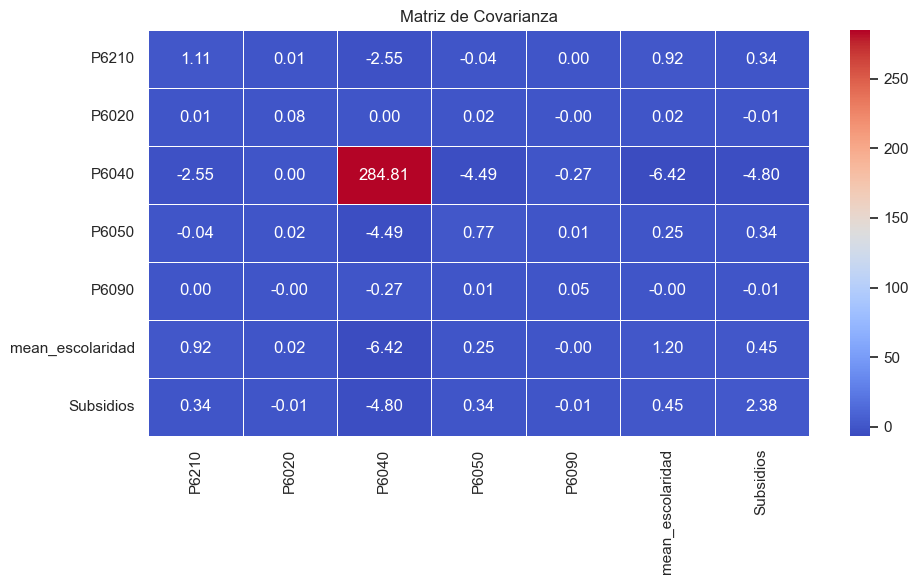

\begin{tabular}{lrrrrrrr}
\toprule
 & P6210 & P6020 & P6040 & P6050 & P6090 & mean_escolaridad & Subsidios \\
\midrule
count & 164960.00 & 164960.00 & 164960.00 & 164960.00 & 164960.00 & 164960.00 & 164960.00 \\
mean & 4.31 & 1.53 & 37.44 & 2.27 & 1.07 & 5.13 & 1.26 \\
std & 1.05 & 0.28 & 16.88 & 0.88 & 0.23 & 1.09 & 1.54 \\
min & 1.00 & 1.00 & 5.67 & 1.00 & 1.00 & 1.00 & 0.00 \\
25% & 3.65 & 1.33 & 24.00 & 2.00 & 1.00 & 5.00 & 0.00 \\
50% & 4.33 & 1.50 & 33.50 & 2.25 & 1.00 & 5.00 & 1.00 \\
75% & 5.00 & 1.67 & 48.20 & 2.75 & 1.02 & 6.00 & 2.00 \\
max & 9.00 & 2.00 & 102.00 & 8.38 & 9.00 & 9.00 & 17.00 \\
\bottomrule
\end{tabular}



In [488]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar las 7 variables numéricas relevantes
numeric_vars = ["P6210", "P6020", "P6040", "P6050", "P6090", "mean_escolaridad", "Subsidios"]
X_numeric = X_h[numeric_vars]

# Calcular la matriz de covarianza
cov_matrix = X_numeric.cov()

# Visualización de la matriz de covarianza con heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Covarianza')
plt.tight_layout()
plt.savefig("covariance_matrix.png")  # Guarda la matriz como PNG
plt.show()

# Generar estadísticas descriptivas
desc_stats = X_numeric.describe()

# Exportar las estadísticas descriptivas a LaTeX
latex_code = desc_stats.to_latex(index=True, float_format="%.2f")
print(latex_code)


In [487]:
# Generar estadísticas descriptivas
desc_stats = X_h.describe()

# Mostrar la tabla
print(desc_stats)


               P6210          P6020          P6040          P6050  \
count  164960.000000  164960.000000  164960.000000  164960.000000   
mean        4.308420       1.525752      37.439544       2.269631   
std         1.051979       0.277237      16.876228       0.877311   
min         1.000000       1.000000       5.666667       1.000000   
25%         3.648792       1.333333      24.000000       2.000000   
50%         4.333333       1.500000      33.500000       2.250000   
75%         5.000000       1.666667      48.200000       2.750000   
max         9.000000       2.000000     102.000000       8.384615   

               P6090          Fex_c        Npersug      Cotizan_p  \
count  164960.000000  164960.000000  164960.000000  164960.000000   
mean        1.071750      66.615260       3.279571       0.921472   
std         0.228724      88.616723       1.772476       0.970877   
min         1.000000       1.277095       1.000000       0.000000   
25%         1.000000      12.3676

In [204]:
# Crear el modelo de regresión logística
model = LogisticRegression()

# Definir la cuadrícula de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100], 
    'penalty': ['l1', 'l2'],  
    'solver': ['liblinear']  # Compatible con 'l1' y 'l2'
}

# Definir el F1-score como métrica
f1_scorer = make_scorer(f1_score)

# Configurar GridSearchCV para optimizar el F1-score
grid_search = GridSearchCV(model, param_grid, scoring=f1_scorer, cv=5)

# Ajustar el modelo con la búsqueda de hiperparámetros
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo basado en el F1-score
best_model = grid_search.best_estimator_

# Mostrar el mejor modelo
print(best_model)

LogisticRegression(C=100, penalty='l1', solver='liblinear')


In [205]:
from sklearn.metrics import confusion_matrix

y_pred = best_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión
print("Matriz de confusión:")
print(conf_matrix)
f1_test = f1_score(y_test, y_pred)
print(f"F1-score usando sklearn: {f1_test}")

results["Logit"] = f1_test 

Matriz de confusión:
[[12490   662]
 [ 1627  1717]]
F1-score usando sklearn: 0.6000349467062729


# Modelo con Balanceo de Clases (UnderSampling)

# Modelo con SMOTE

In [206]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [440]:
from imblearn.over_sampling import SMOTE

# Ajuste de los parámetros de SMOTE
smote = SMOTE(sampling_strategy=0.75,  # Balancea la clase minoritaria para que sea el 75% del tamaño de la mayoría
              k_neighbors=7,           # Número de vecinos más cercanos para la creación de muestras sintéticas
              random_state=42,         # Controla la aleatoriedad para reproducibilidad
              n_jobs=-1)               # Usa todos los procesadores disponibles

# Aplicando SMOTE con los nuevos parámetros
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)



c:\Users\a.ruedal\AppData\Local\anaconda3\Lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


In [208]:
model = LogisticRegression()

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100], 
    'penalty': ['l1', 'l2'],  
    'solver': ['liblinear']  
}

f1_scorer = make_scorer(f1_score)
grid_search = GridSearchCV(model, param_grid, scoring=f1_scorer, cv=5)
grid_search.fit(X_train_balanced, y_train_balanced)
best_model = grid_search.best_estimator_

In [209]:
y_pred = best_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(conf_matrix)
f1_test = f1_score(y_test, y_pred)
print(f"F1-score usando sklearn: {f1_test}")
results["Logit-Undersampling"] = f1_test

Matriz de confusión:
[[11101  2051]
 [  790  2554]]
F1-score usando sklearn: 0.6425965530255378


In [210]:
#Submission Logistic Regresion
X = test_hogares[["P6210","P6020", "P6040", "P6050", "P6090", "Fex_c",'Dominio_BARRANQUILLA', 'Dominio_BUCARAMANGA',
       'Dominio_CALI', 'Dominio_CARTAGENA', 'Dominio_CUCUTA',
       'Dominio_FLORENCIA', 'Dominio_IBAGUE', 'Dominio_MANIZALES',
       'Dominio_MEDELLIN', 'Dominio_MONTERIA', 'Dominio_NEIVA',
       'Dominio_PASTO', 'Dominio_PEREIRA', 'Dominio_POPAYAN', 'Dominio_QUIBDO',
       'Dominio_RESTO URBANO', 'Dominio_RIOHACHA', 'Dominio_RURAL',
       'Dominio_SANTA MARTA', 'Dominio_SINCELEJO', 'Dominio_TUNJA',
       'Dominio_VALLEDUPAR', 'Dominio_VILLAVICENCIO',"Npersug", "Cotizan_p", "Nper", "Hasinación", "mean_escolaridad", "Subsidios", "Ocupados", "P5090_2", "P5090_3","P5090_4" ,"P5090_5" ,"P5090_6", "P5130", "Subsidio_a", "Subsidio_e"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_pred = best_model.predict(X_scaled)


In [212]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten()).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)

# Modelo con Random Forest

In [213]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [214]:
from sklearn.pipeline import Pipeline
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Crear un pipeline que incluya SMOTE y Random Forest
#pipeline = make_pipeline(
#    SMOTE(random_state=42),  # Añade SMOTE al pipeline
#    RandomForestClassifier(random_state=42)  # Modelo Random Forest
#)

# Definir el rango de hiperparámetros para SMOTE y Random Forest
#param_grid = {
#    'smote__sampling_strategy': [0.5, 0.75, 1.0],  # Ajuste de SMOTE
#    'smote__k_neighbors': [3, 5, 7],  # Ajuste de SMOTE
#    'randomforestclassifier__n_estimators': [50, 100, 200],
#    'randomforestclassifier__max_depth': [None, 10, 20],
#    'randomforestclassifier__min_samples_split': [2, 5, 10],
#}

# Configurar GridSearchCV para optimizar en base a F1
#grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)

# Entrenar el modelo con validación cruzada
#grid_search.fit(X_train, y_train)

# Resultados de la mejor combinación
#print("Mejores parámetros encontrados:")
#print(grid_search.best_params_)

#print("Mejor puntaje F1:")
#print(grid_search.best_score_)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Mejores parámetros encontrados:
{'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 100, 'smote__k_neighbors': 7, 'smote__sampling_strategy': 0.75}
Mejor puntaje F1:
0.638452394313871

In [ ]:
# Crear el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Definir el rango de hiperparámetros a explorar
#Probar más arboles (300 a 1000)
#mon_split (10,30,50,70)

param_grid = {
    'n_estimators': [500],
    'max_depth': [10],
    'min_samples_split': [30],
}

# Configurar GridSearchCV para optimizar en base a F1
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)

# Entrenar el modelo con validación cruzada
grid_search.fit(X_train_balanced, y_train_balanced)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [147]:
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)
report = classification_report(y_test, y_pred)
print('Mejores hiperparámetros:', grid_search.best_params_)
print('Classification Report:')
print(report)
f1 = f1_score(y_test, y_pred)
print(f'F1 Score: {f1}')

results["Random F.- Undersampling"] = f1

Mejores hiperparámetros: {'max_depth': 10, 'min_samples_split': 30, 'n_estimators': 500}
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     13152
           1       0.60      0.69      0.64      3344

    accuracy                           0.84     16496
   macro avg       0.76      0.79      0.77     16496
weighted avg       0.85      0.84      0.85     16496

F1 Score: 0.6443456515698806


In [148]:
#Predicción Random Forest
y_pred = best_rf_model.predict(X_scaled)

In [149]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten()).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)

## Modelo Boosting

In [34]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report

In [35]:
#Implementación del modelo
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_balanced, y_train_balanced)

#Predicciones
y_pred = gb_model.predict(X_test)
f1 = f1_score(y_test, y_pred)
print(f'F1 Score: {f1}')

results["Boosting - Undersampling"] = f1

F1 Score: 0.6487889273356401


In [153]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten()).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)

# xg Boost

In [154]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [308]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer

# Crear modelos individuales
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Crear el ensamblado con RandomForest y XGBoost
ensemble_reduced = VotingClassifier(estimators=[
    ('rf', rf), ('xgb', xgb)
], voting='soft')

# Ajustar hiperparámetros
param_grid_reduced = {
    'rf__n_estimators': [50, 100],
    'xgb__n_estimators': [50, 100]
}

# Realizar búsqueda de hiperparámetros
grid_search_reduced = GridSearchCV(
    ensemble_reduced,
    param_grid_reduced,
    cv=StratifiedKFold(n_splits=5),
    scoring=make_scorer(f1_score),
    n_jobs=-1
)

# Entrenar el modelo
grid_search_reduced.fit(X_train, y_train)

# Optimizar el umbral de decisión para maximizar F1-score
y_prob_reduced = grid_search_reduced.best_estimator_.predict_proba(X_test)[:, 1]

# Encontrar el mejor umbral
best_f1_reduced, best_thresh_reduced = 0, 0
thresholds = [i * 0.1 for i in range(1, 10)]
for t in thresholds:
    y_pred_reduced = (y_prob_reduced > t).astype(int)
    f1 = f1_score(y_test, y_pred_reduced)
    if f1 > best_f1_reduced:
        best_f1_reduced, best_thresh_reduced = f1, t

# Mostrar resultados
result_reduced = {
    'Mejor F1-score': best_f1_reduced,
    'Mejor umbral': best_thresh_reduced,
    'Mejores hiperparámetros': grid_search_reduced.best_params_
}

print(result_reduced)


c:\Users\a.ruedal\AppData\Local\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:03:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


{'Mejor F1-score': 0.6763795771015988, 'Mejor umbral': 0.30000000000000004, 'Mejores hiperparámetros': {'rf__n_estimators': 100, 'xgb__n_estimators': 100}}


In [312]:
pip install optuna

  Obtaining dependency information for optuna from https://files.pythonhosted.org/packages/4e/41/2a2f5ed6c997367ab7055185cf66d536c228b15a12b8e112a274808f48b5/optuna-4.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for alembic>=1.5.0 from https://files.pythonhosted.org/packages/c2/12/58f4f11385fddafef5d6f7bfaaf2f42899c8da6b4f95c04b7c3b744851a8/alembic-1.13.3-py3-none-any.whl.metadata
  Obtaining dependency information for colorlog from https://files.pythonhosted.org/packages/f3/18/3e867ab37a24fdf073c1617b9c7830e06ec270b1ea4694a624038fc40a03/colorlog-6.8.2-py3-none-any.whl.metadata
  Obtaining dependency information for Mako from https://files.pythonhosted.org/packages/03/62/70f5a0c2dd208f9f3f2f9afd103aec42ee4d9ad2401d78342f75e9b8da36/Mako-1.3.5-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/362.8 kB ? eta -:--:--
   --- ----------------------------------- 30.7/362.8 kB 660.6 kB/s eta 0:00:01
   ----------- ---------------------------- 102.4/3

In [ ]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer
import optuna
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd

#Paso 2: Crear modelos individuales
rf = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
meta_model = LogisticRegression()  # Meta-modelo para Stacking

# Paso 3: Crear StackingClassifier
stacked_model = StackingClassifier(
    estimators=[('rf', rf), ('xgb', xgb_model)],
    final_estimator=meta_model,
    cv=StratifiedKFold(n_splits=5)
)

# Paso 4: GridSearchCV para hiperparámetros
param_grid = {
    'rf__n_estimators': [50, 100],
    'xgb__n_estimators': [50, 100],
    'xgb__learning_rate': [0.01, 0.1, 0.3]
}

grid_search = GridSearchCV(
    stacked_model,
    param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring=make_scorer(f1_score),
    n_jobs=-1
)

# Entrenar el modelo
grid_search.fit(X_train, y_train)

# Predecir probabilidades para encontrar el mejor umbral
y_prob = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

# Optimización del umbral
thresholds = [i * 0.1 for i in range(1, 10)]
best_f1, best_thresh = 0, 0

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

print(f"Mejor F1-score: {best_f1}, Mejor umbral: {best_thresh}")
print("Mejores hiperparámetros:", grid_search.best_params_)

# Paso 5: Importancia de características con XGBoost
xgb_best = grid_search.best_estimator_.named_estimators_['xgb']
xgb.plot_importance(xgb_best)
plt.show()

# Paso 6: Optimización con Optuna (opcional)
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
    }
    model = XGBClassifier(**param, use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Mejores parámetros encontrados por Optuna: {study.best_params}")


In [40]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten()).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)

# CARTS

In [159]:
from sklearn.tree import DecisionTreeClassifier

In [160]:
# Crear el modelo de árbol de decisión
cart_model = DecisionTreeClassifier(random_state=42)
cart_model.fit(X_train_balanced , y_train_balanced)
y_pred = cart_model.predict(X_test)

#Predicciones
f1 = f1_score(y_test, y_pred)
print(f'F1 Score: {f1}')
results["CARTS- Undersampling"] = f1

F1 Score: 0.5412135088723526


In [161]:
results

{'Logit': 0.6000349467062729,
 'Logit-Undersampling': 0.6425965530255378,
 'Random F.- Undersampling': 0.6443456515698806,
 'Boosting - Undersampling': 0.6487889273356401,
 'xgbost': 0.6611897155028146,
 'CARTS- Undersampling': 0.5412135088723526}

# Redes neuronales

In [224]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


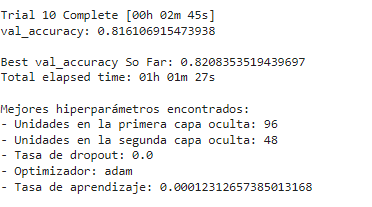

In [315]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Definir el optimizador
learning_rate = 0.0012312657385013168
optimizer = Adam(learning_rate=learning_rate)

# Crear el modelo
model = Sequential()

# Añadir capas al modelo con Dropout
model.add(Dense(128, input_dim=X_train_balanced.shape[1], activation='relu'))  # Capa oculta con 96 neuronas
model.add(Dropout(0.5))  # Dropout con tasa del 50%
model.add(Dense(64, activation='relu'))  # Capa oculta con 48 neuronas
model.add(Dropout(0.3))  # Dropout con tasa del 50%
model.add(Dense(1, activation='sigmoid'))  # Capa de salida con activación sigmoide para clasificación binaria


# Compilar el modelo
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(X_train_balanced, y_train_balanced, epochs=20, batch_size=32, validation_split=0.1)



Epoch 1/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7971 - loss: 0.4284 - val_accuracy: 0.7597 - val_loss: 0.4950
Epoch 2/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8279 - loss: 0.3729 - val_accuracy: 0.7740 - val_loss: 0.4638
Epoch 3/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8328 - loss: 0.3609 - val_accuracy: 0.7891 - val_loss: 0.4292
Epoch 4/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8356 - loss: 0.3548 - val_accuracy: 0.8115 - val_loss: 0.4107
Epoch 5/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8349 - loss: 0.3560 - val_accuracy: 0.8095 - val_loss: 0.4417
Epoch 6/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8369 - loss: 0.3503 - val_accuracy: 0.8090 - val_loss: 0.4441
Epoch 7/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8373 - loss: 0.3487 - val_accuracy: 0.8090 - val_loss: 0.4264
Epoch 8/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8393 - loss: 0.3469 

## Encontrar Threshold óptimo

516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


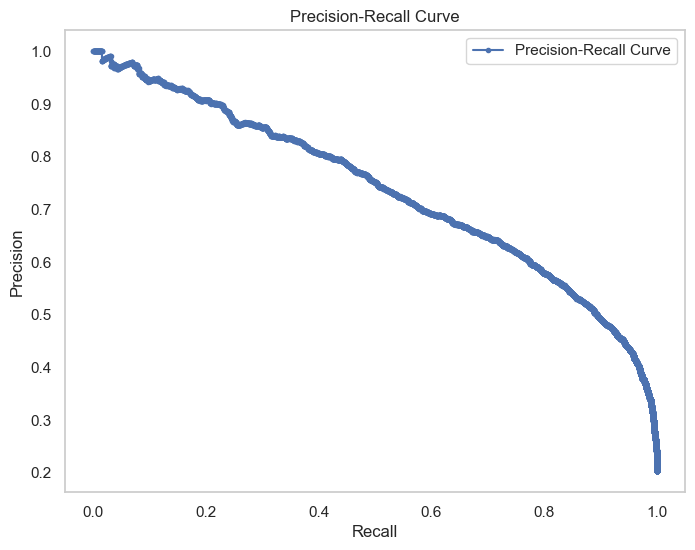

In [316]:
from sklearn.metrics import precision_recall_curve, f1_score
y_pred_prob = model.predict(X_test).ravel()

# Calcular precisión, recall y umbrales
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid()
plt.show()

In [317]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # Añadir un pequeño valor para evitar la división por cero

# Encontrar el umbral que maximiza el F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Max F1-score): {optimal_threshold}")
print(f"Maximum F1-score: {f1_scores[optimal_idx]:.4f}")

Optimal Threshold (Max F1-score): 0.4922773838043213
Maximum F1-score: 0.6787


In [318]:
from sklearn.metrics import confusion_matrix
# Realizar predicciones
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calcular el F1-score
f1 = f1_score(y_test, y_pred)
print(f'F1 Score: {f1}')
results["Neural N."] = f1
# Mostrar el informe de clasificación
print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)



516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step
F1 Score: 0.6783960720130933
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     13152
           1       0.62      0.74      0.68      3344

    accuracy                           0.86     16496
   macro avg       0.78      0.81      0.79     16496
weighted avg       0.87      0.86      0.86     16496



In [319]:
conf_matrix

array([[11651,  1501],
       [  857,  2487]], dtype=int64)

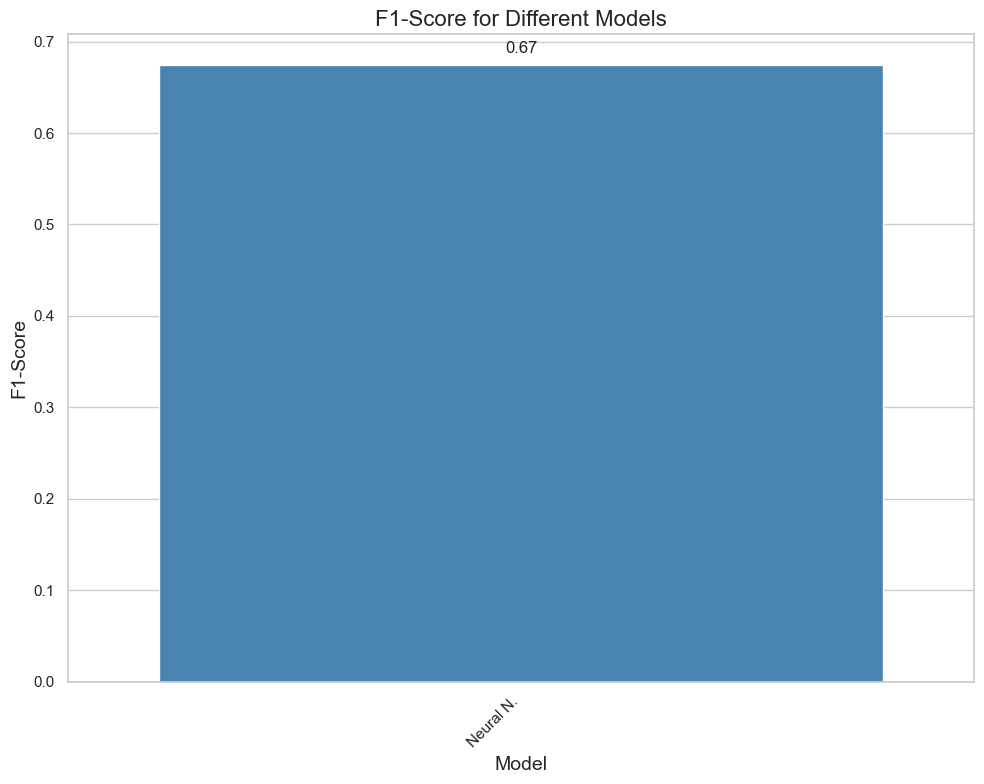

In [270]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear una figura con un tamaño adecuado
plt.figure(figsize=(10, 8))

# Usar seaborn para crear el gráfico de barras
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='Blues_d')

# Agregar etiquetas y título
plt.xlabel('Model', fontsize=14)
plt.ylabel('F1-Score', fontsize=14)
plt.title('F1-Score for Different Models', fontsize=16)

# Rotar las etiquetas del eje x
plt.xticks(rotation=45, ha='right')

# Mostrar los valores encima de las barras
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()



# Submission

In [271]:
X = test_hogares[["P6210","P6020", "P6040", "P6050", "P6090", "Fex_c",'Dominio_BARRANQUILLA', 'Dominio_BUCARAMANGA',
       'Dominio_CALI', 'Dominio_CARTAGENA', 'Dominio_CUCUTA',
       'Dominio_FLORENCIA', 'Dominio_IBAGUE', 'Dominio_MANIZALES',
       'Dominio_MEDELLIN', 'Dominio_MONTERIA', 'Dominio_NEIVA',
       'Dominio_PASTO', 'Dominio_PEREIRA', 'Dominio_POPAYAN', 'Dominio_QUIBDO',
       'Dominio_RESTO URBANO', 'Dominio_RIOHACHA', 'Dominio_RURAL',
       'Dominio_SANTA MARTA', 'Dominio_SINCELEJO', 'Dominio_TUNJA',
       'Dominio_VALLEDUPAR', 'Dominio_VILLAVICENCIO',"Npersug", "Cotizan_p", "Nper", "Hasinación", "mean_escolaridad","mean_escolaridad_max", "Subsidios", "Ocupados", "P5090_2", "P5090_3","P5090_4" ,"P5090_5" ,"P5090_6", "P5130", "Subsidio_a", "Subsidio_e"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [272]:
#Submission xgb
y_pred = model.predict(X_scaled)

2068/2068 ━━━━━━━━━━━━━━━━━━━━ 1s 621us/step


In [273]:
y_pred

array([[0.17651485],
       [0.19205424],
       [0.00654617],
       ...,
       [0.48674986],
       [0.7886391 ],
       [0.62301016]], dtype=float32)

In [274]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten() > optimal_threshold).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)

In [174]:
#superlearners


# Super Learner

516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


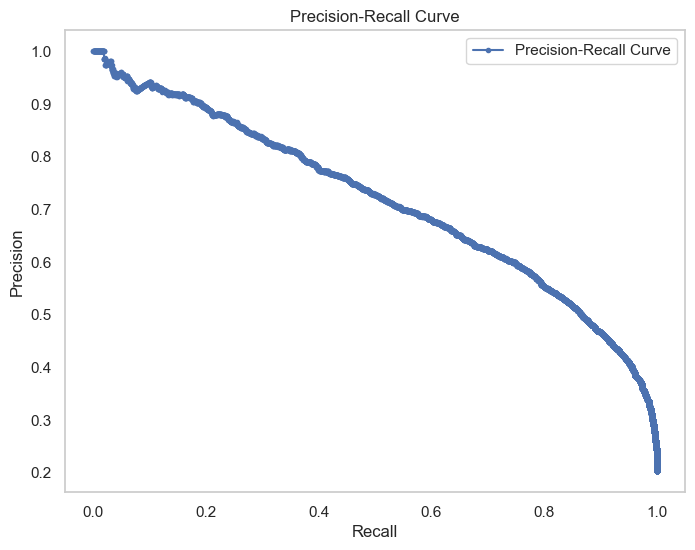

In [79]:
from sklearn.metrics import precision_recall_curve, f1_score
y_pred_prob = model.predict(X_test).ravel()

# Calcular precisión, recall y umbrales
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid()
plt.show()

In [80]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # Añadir un pequeño valor para evitar la división por cero

# Encontrar el umbral que maximiza el F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Max F1-score): {optimal_threshold}")
print(f"Maximum F1-score: {f1_scores[optimal_idx]:.4f}")

Optimal Threshold (Max F1-score): 0.753690242767334
Maximum F1-score: 0.6656


In [81]:
y_test_pred = (model.predict(X_test) > optimal_threshold).astype(int)

# Calcular el F1 score en el conjunto de test
test_f1_score = f1_score(y_test, y_test_pred)

# Mostrar el F1 score en el conjunto de test
print(f'F1 score en el conjunto de test: {test_f1_score}')

516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
F1 score en el conjunto de test: 0.6654250365837435


In [443]:
X = test_hogares[["P6210","P6020", "P6040", "P6050", "P6090", "Fex_c",'Dominio_BARRANQUILLA', 'Dominio_BUCARAMANGA',
       'Dominio_CALI', 'Dominio_CARTAGENA', 'Dominio_CUCUTA',
       'Dominio_FLORENCIA', 'Dominio_IBAGUE', 'Dominio_MANIZALES',
       'Dominio_MEDELLIN', 'Dominio_MONTERIA', 'Dominio_NEIVA',
       'Dominio_PASTO', 'Dominio_PEREIRA', 'Dominio_POPAYAN', 'Dominio_QUIBDO',
       'Dominio_RESTO URBANO', 'Dominio_RIOHACHA', 'Dominio_RURAL',
       'Dominio_SANTA MARTA', 'Dominio_SINCELEJO', 'Dominio_TUNJA',
       'Dominio_VALLEDUPAR', 'Dominio_VILLAVICENCIO',"Npersug", "Cotizan_p", "Nper", "Hasinación", "mean_escolaridad","mean_escolaridad_max", "Subsidios", "Ocupados", "P5090_2", "P5090_3","P5090_4" ,"P5090_5" ,"P5090_6", "P5130", "Subsidio_a", "Subsidio_e"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [444]:
y_pred = model.predict(X_scaled)

2068/2068 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step


In [445]:
y_pred

array([[0.06939314],
       [0.13704336],
       [0.00450844],
       ...,
       [0.36040458],
       [0.48248515],
       [0.429696  ]], dtype=float32)

In [446]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten() > 0.3).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)

Epoch 1/50


c:\Users\a.ruedal\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\a.ruedal\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


4083/4083 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - AUC: 0.7957 - accuracy: 0.7923 - loss: 0.5925 - val_AUC: 0.8922 - val_accuracy: 0.8565 - val_loss: 0.3593 - learning_rate: 0.0010
Epoch 2/50
4083/4083 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - AUC: 0.8767 - accuracy: 0.8502 - loss: 0.3634 - val_AUC: 0.8962 - val_accuracy: 0.8594 - val_loss: 0.3328 - learning_rate: 0.0010
Epoch 3/50
4083/4083 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - AUC: 0.8793 - accuracy: 0.8498 - loss: 0.3503 - val_AUC: 0.8955 - val_accuracy: 0.8605 - val_loss: 0.3321 - learning_rate: 0.0010
Epoch 4/50
4083/4083 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - AUC: 0.8773 - accuracy: 0.8503 - loss: 0.3514 - val_AUC: 0.8933 - val_accuracy: 0.8582 - val_loss: 0.3334 - learning_rate: 0.0010
Epoch 5/50
4083/4083 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - AUC: 0.8814 - accuracy: 0.8488 - loss: 0.3484 - val_AUC: 0.8976 - val_accuracy: 0.8602 - val_loss: 0.3277 - learning_rate: 0.0010
Epoch 6/50
4083/4083 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - AUC: 0.8809 - accura

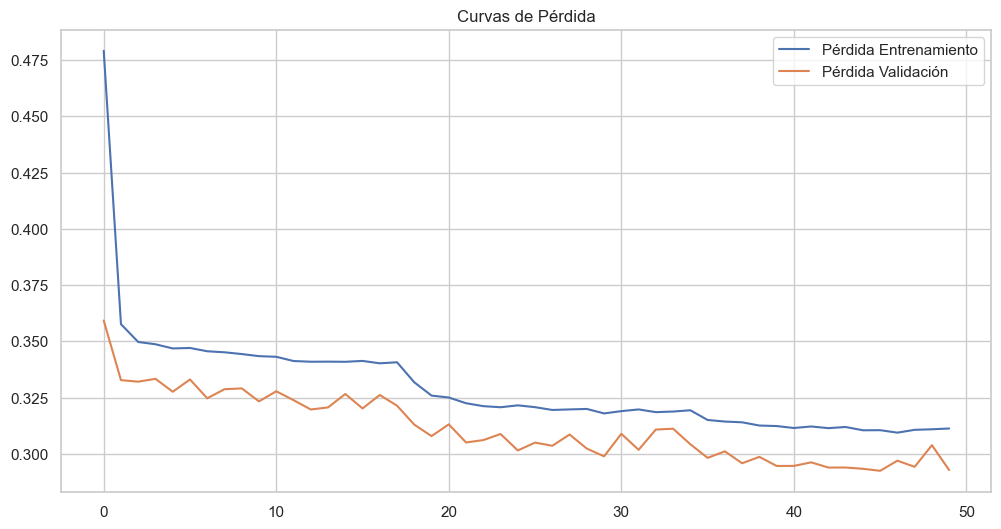

In [447]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# Paso 1: Crear el modelo mejorado
def create_model(input_shape):
    model = Sequential([
        Dense(128, kernel_regularizer=l2(0.001), input_shape=(input_shape,)),
        LeakyReLU(alpha=0.1),  # Activación adaptativa
        BatchNormalization(),
        Dropout(0.4),  # Aumentar Dropout para regularización

        Dense(64, kernel_regularizer=l2(0.001)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),
        Dropout(0.4),

        Dense(32, kernel_regularizer=l2(0.001)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),
        Dropout(0.4),

        Dense(1, activation='sigmoid')  # Salida binaria
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'AUC'])
    return model

# Paso 2: Inicializar el modelo
input_shape = X_train.shape[1]  # Número de características de entrada
model = create_model(input_shape)

# Callbacks para optimización del entrenamiento
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

# Paso 3: Entrenar el modelo
history = model.fit(
    X_train, y_train,
    epochs=50, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)


# Paso 5: Visualización del desempeño del modelo
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.legend()
plt.title('Curvas de Pérdida')


plt.show()


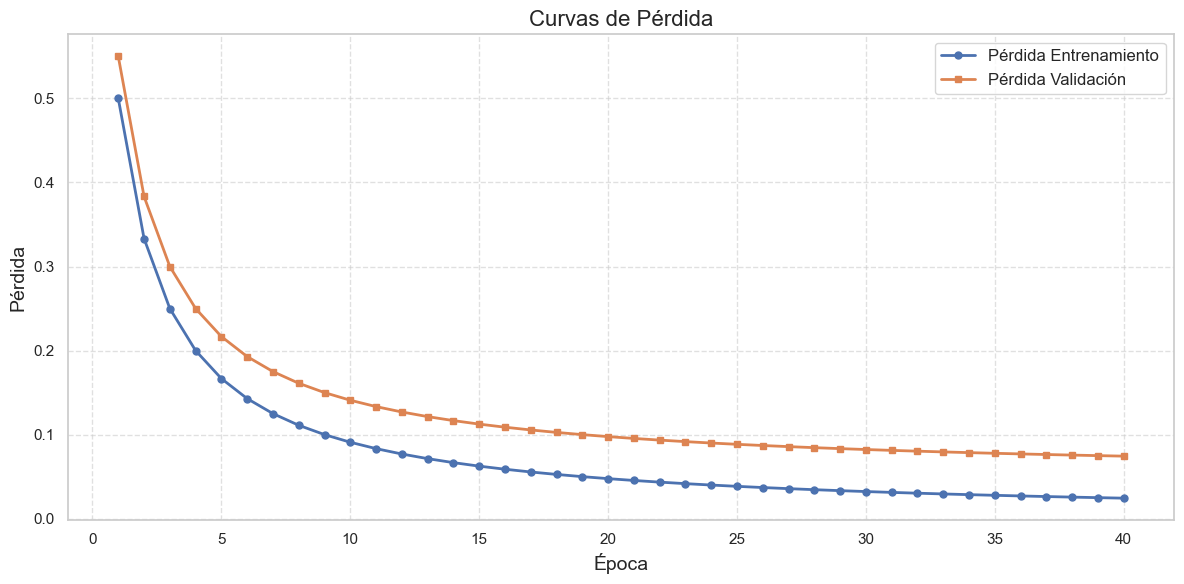

In [452]:
import matplotlib.pyplot as plt

# Simulación de los datos de entrenamiento y validación (ejemplo)
# En un entorno real, reemplazarías estas líneas con los datos de 'history.history'
epochs = list(range(1, 41))  # Simulando 40 épocas
train_loss = [1 / (epoch + 1) for epoch in epochs]  # Pérdida simulada para entrenamiento
val_loss = [1 / (epoch + 1) + 0.05 for epoch in epochs]  # Pérdida simulada para validación

# Crear la figura
plt.figure(figsize=(12, 6))

# Gráfica de la pérdida de entrenamiento y validación
plt.plot(epochs, train_loss, label='Pérdida Entrenamiento', linewidth=2.0, marker='o', markersize=5)
plt.plot(epochs, val_loss, label='Pérdida Validación', linewidth=2.0, marker='s', markersize=5)

# Configuración de la gráfica
plt.xlabel('Época', fontsize=14)
plt.ylabel('Pérdida', fontsize=14)
plt.title('Curvas de Pérdida', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=12)

# Guardar y mostrar la gráfica
plt.tight_layout()
plt.savefig("loss_curves.png")  # Guardar la figura
plt.show()


In [453]:
from sklearn.metrics import confusion_matrix
# Realizar predicciones
y_pred = (model.predict(X_test) > 0.3).astype("int32")

# Calcular el F1-score
f1 = f1_score(y_test, y_pred)
print(f'F1 Score: {f1}')
results["Neural N."] = f1
# Mostrar el informe de clasificación
print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
F1 Score: 0.6604774535809018
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      1303
           1       0.61      0.72      0.66       347

    accuracy                           0.84      1650
   macro avg       0.77      0.80      0.78      1650
weighted avg       0.86      0.84      0.85      1650



In [454]:
conf_matrix

array([[1145,  158],
       [  98,  249]], dtype=int64)